Feature Importance  - general behavior before mandates - covid model  

In [5]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import joblib

In [6]:
# downloadig data from the rf model code

# before mandates train set
before_train_general_behav = pd.read_csv("before_train_general_behav.csv")

# remove the target variables and identifiers
drop_cols = ['RecordNo', 'Date','face_mask_scale', 'face_mask_binary','general_protective_behavior_scale',
              'general_protective_behavior_binary','mandate_start_date']


# train set
x_train = before_train_general_behav.drop(columns=drop_cols)
x_train = x_train.astype(float)  # boolean to int

# target variable
y_train = before_train_general_behav["general_protective_behavior_binary"]


# best rf model 
rf = joblib.load("general_behav_before_covidModel_RF_rolling.pkl")

# best rf hyper parameters
best_parameters = joblib.load("general_behav_before_covidModel_RF_bestParameters_rolling.pkl")

In [7]:
best_parameters

{'rf__max_depth': 10,
 'rf__max_features': 'sqrt',
 'rf__min_samples_leaf': 1,
 'rf__min_samples_split': 2,
 'rf__n_estimators': 250}

100 runs to store all features

In [8]:
# to keep all the importances in each run
all_importances = []


for i in range(100):

    temp_rf = Pipeline([
        ('ros', RandomOverSampler(random_state=i)),
        ('rf', RandomForestClassifier(random_state=i,
                                      n_jobs=-1))
    ])

    temp_rf.set_params(**best_parameters)

    temp_rf.fit(x_train, y_train)

    all_importances.append(
        temp_rf.named_steps["rf"].feature_importances_
    )



median - Feature Importance -  For stability

Feature Importance                                Feature  Importance
6     protective_behavior_nomask_scale    0.626159
0               Non-household contacts    0.076133
4                   Perceived Severity    0.049455
8                  7days_rolling_cases    0.036039
1                                  age    0.018369
7                                 week    0.017992
5             Perceived Susceptibility    0.016066
19               state_New South Wales    0.015071
3                            Wellbeing    0.011726
2                       household_size    0.009250
12               Isolate if unwell_Yes    0.009197
17  Isolate if instructed_Very willing    0.008795
11          Isolate if unwell_Not sure    0.007884
9                 7days_rolling_deaths    0.004387
25             state_Western Australia    0.004017


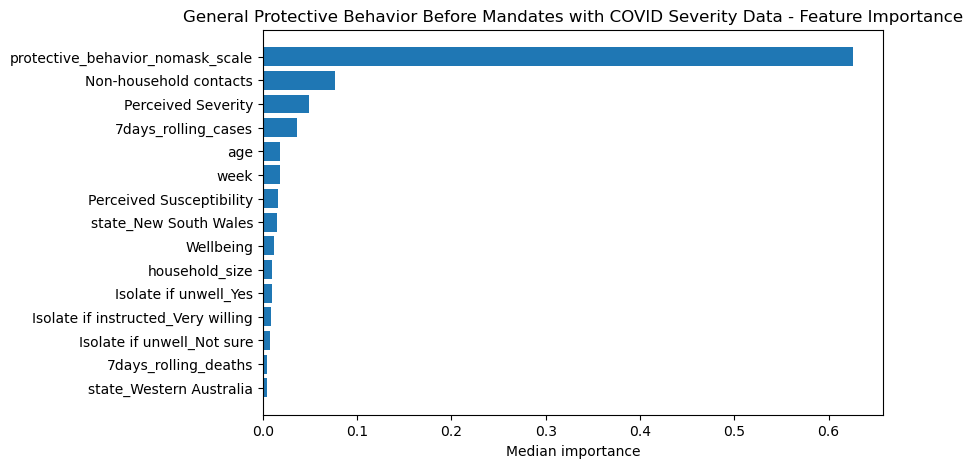

In [9]:
all_importances = np.array(all_importances)

# take the median / mean
median_importance = np.median(all_importances, axis=0) # take the median of each column(feature) 


feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": median_importance
})

feature_importance = feature_importance.sort_values("Importance",ascending=False)

top15 = feature_importance.head(15)

print(f"Feature Importance",top15)
feature_importance.to_csv("general_behav_before_covidModel_RF_FeatureImportance_rolling.csv",index=False)


# plot
plt.figure(figsize=(8,5))
plt.barh(top15["Feature"], top15["Importance"])
plt.title("General Protective Behavior Before Mandates with COVID Severity Data - Feature Importance")
plt.xlabel("Median importance")
plt.gca().invert_yaxis()
plt.savefig("general_behav_before_covidModel_RF_FeatureImportance_rolling.png",dpi=300,bbox_inches="tight")
plt.show()


mean - Feature Importance -  For stability

Feature Importance                                Feature  Importance
6     protective_behavior_nomask_scale    0.626159
0               Non-household contacts    0.076133
4                   Perceived Severity    0.049455
8                  7days_rolling_cases    0.036039
1                                  age    0.018369
7                                 week    0.017992
5             Perceived Susceptibility    0.016066
19               state_New South Wales    0.015071
3                            Wellbeing    0.011726
2                       household_size    0.009250
12               Isolate if unwell_Yes    0.009197
17  Isolate if instructed_Very willing    0.008795
11          Isolate if unwell_Not sure    0.007884
9                 7days_rolling_deaths    0.004387
25             state_Western Australia    0.004017


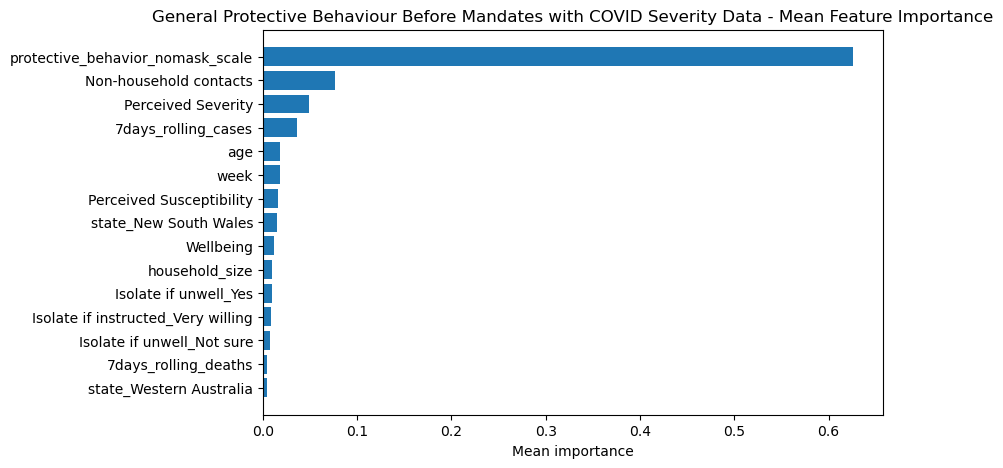

In [10]:
# take the mean
mean_importance = np.mean(all_importances, axis=0) # take the mean of each column(feature) 


feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": median_importance
})

feature_importance = feature_importance.sort_values("Importance",ascending=False)

top15 = feature_importance.head(15)

print(f"Feature Importance",top15)
# feature_importance.to_csv("facemask_before_covidModel_RF_FeatureImportance_rolling.csv",index=False)


# plot
plt.figure(figsize=(8,5))
plt.barh(top15["Feature"], top15["Importance"])
plt.title("General Protective Behaviour Before Mandates with COVID Severity Data - Mean Feature Importance")
plt.xlabel("Mean importance")
plt.gca().invert_yaxis()
plt.show()


# plt.tight_layout()
# plt.savefig("facemask_before_covidModel_RF_FeatureImportance_rolling.png",dpi=300,bbox_inches="tight")

Mean and Median Importance are similar.